# Working with a larger example (Multi-class Classification)

We'll be building a neural network for fashion company to classify images for different clothing items.

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted inot training and test sets
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Show the first training example
print(f"Training sample:{train_data[0]}/n")
print(f"Training Labels:{train_labels[0]}")

Training sample:[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   

In [ ]:
# Check how many samples of each label exists
unique, counts = np.unique(train_labels, return_counts=True)
dict(zip(unique, counts))

{np.uint8(0): np.int64(6000),
 np.uint8(1): np.int64(6000),
 np.uint8(2): np.int64(6000),
 np.uint8(3): np.int64(6000),
 np.uint8(4): np.int64(6000),
 np.uint8(5): np.int64(6000),
 np.uint8(6): np.int64(6000),
 np.uint8(7): np.int64(6000),
 np.uint8(8): np.int64(6000),
 np.uint8(9): np.int64(6000)}

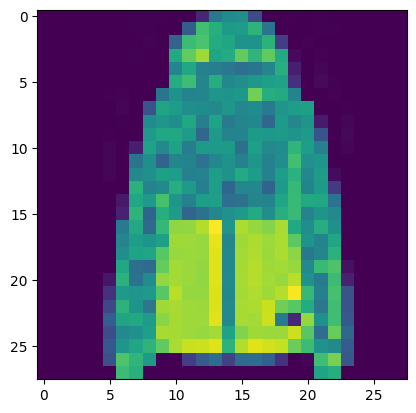

In [ ]:
# Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[22])

In [ ]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [ ]:
# Create a small list so we can index our labels to
label_list = ["T-shirt/Top", "Trouser", "PullOver", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

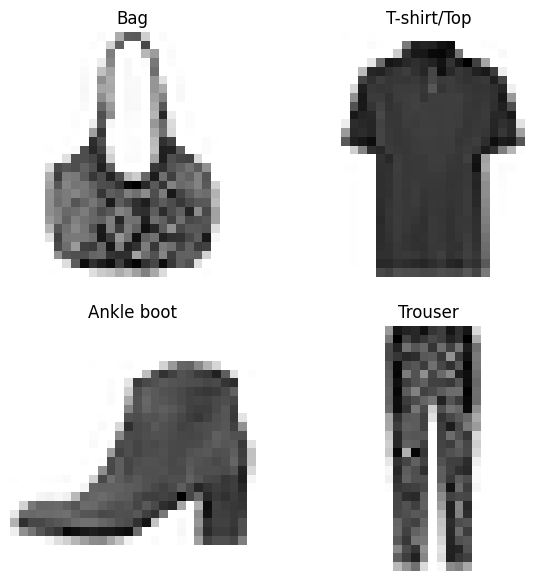

In [ ]:
# Plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7, 7))
for i in range(4):
  ax = plt.subplot(2, 2, i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(label_list[train_labels[rand_index]])
  plt.axis(False)

# Building a Multi-class Classification Model
* Input shape = 28 by 28
* Output shape = 10
* Loss function = Sparse Categorical CrossEntropy
* Output activation = Softmax
* Hidden activation = ReLU
* Optimizer = Adam

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(0.001),
              metrics=["accuracy"])

# Fit the model
model.fit(train_data, train_labels, epochs=100, verbose=0)

In [ ]:
# Save the model
model.save("fashion_mnist_model.h5")

In [ ]:
# Load the model
model = tf.keras.models.load_model("fashion_mnist_model.h5")

In [ ]:
# Evaluate the model
model.evaluate(test_data, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5537 - loss: 1.1430


[1.1429730653762817, 0.5536999702453613]

In [ ]:
# Make predictions on the test data
y_preds = model.predict(test_data)
y_preds

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.52460435e-04, 0.00000000e+00, 9.99447525e-01],
       [1.45749837e-05, 1.63542208e-10, 9.96714115e-01, ...,
        0.00000000e+00, 3.66033461e-08, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [9.62714441e-09, 0.00000000e+00, 5.88705085e-29, ...,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.14970411e-09, 0.00000000e+00, 1.17105625e-14]], dtype=float32)

In [ ]:
# get prediction labels
def get_pred_label(prediction_prob):
  return label_list[np.argmax(prediction_prob)]

In [ ]:
pred_label = get_pred_label(y_preds[1])
pred_label

'PullOver'

In [ ]:
pred_array = [np.argmax(y_preds[n]) for n in range(len(y_preds))]
len(pred_array)

10000

In [ ]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

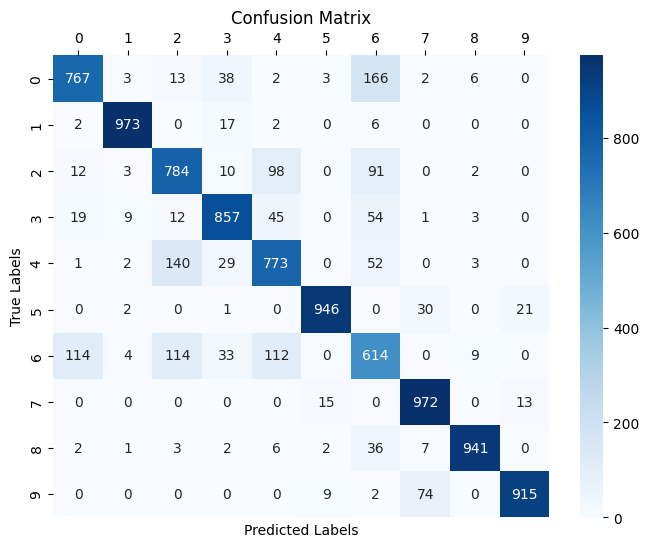

In [ ]:
# plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, pred_array)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=set(test_labels),
            yticklabels=set(test_labels))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
# Move x-axis ticks to the top
ax.xaxis.set_ticks_position("top")
plt.show()

How can we get our data into numbers between 0 and 1(Normalization).

We can do this by dividing the data by the maximum value

In [ ]:
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

# Check the min and max of the scaled data
train_data_norm.min(), train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
train_data_norm.shape

(60000, 28, 28)

In [ ]:
# Now lets train our model using our normalised data
tf.random.set_seed(42)

# Build the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Add EarlyStopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                  patience=5,
                                                  restore_best_weights=True)

# Learning Rate Scheduler
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                     factor=0.5,
                                                     patience=3,
                                                     min_lr=1e-4)

# Compile the model
model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])

norm_history = model_1.fit(train_data_norm, train_labels, epochs=200, validation_split=0.1, callbacks=[early_stopping, lr_scheduler], verbose=0)

In [ ]:
model_1.evaluate(test_data_norm, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.3687


[0.3687395751476288, 0.8801000118255615]

<Axes: title={'center': 'Non-normalised data'}>

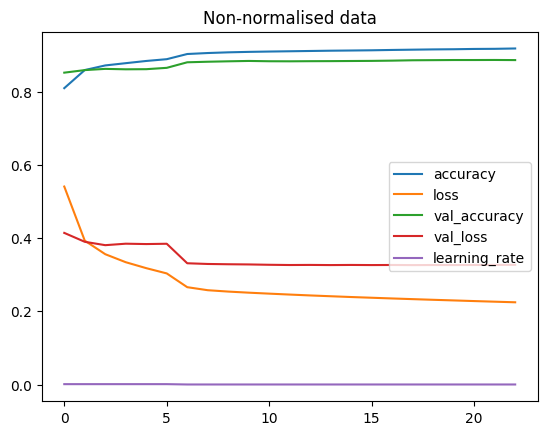

In [ ]:
# Plot normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Non-normalised data")

In [ ]:
# Finding the ideal learning rate
tf.random.set_seed(42)
# Build model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
# compile the model
model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * (10**epoch/20))

lr_history = model_2.fit(train_data_norm, train_labels, epochs=100, verbose=1, callbacks=[lr_scheduler])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6595 - loss: 1.0886 - learning_rate: 5.0000e-05
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8304 - loss: 0.4821 - learning_rate: 5.0000e-04
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8306 - loss: 0.4675 - learning_rate: 0.0050
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1032 - loss: 2.3267 - learning_rate: 0.0500
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1024 - loss: 2.3610 - learning_rate: 0.5000
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0983 - loss: 2.8680 - learning_rate: 5.0000
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1001 - loss: 34.4781 - learning_rate: 50.0000
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0993 - loss: 316.3301 - learning_rate: 500.0000
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1008 - loss: 

In [ ]:
# Evaluate the model
model_2.evaluate(test_data_norm, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1000 - loss: 204.2745


[204.27450561523438, 0.10000000149011612]

ValueError: x and y must have same first dimension, but have shapes (100,) and (8,)

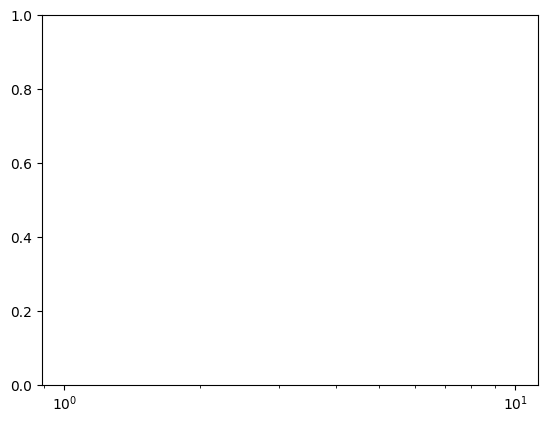

In [ ]:
# Plot the learning rate decay curve
import matplotlib.pyplot as plt
# Create a set of numbers for the X-axis
lrs = 1e-3 * (10**(tf.range(00)/20))
plt.semilogx(lrs, lr_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("loss")
plt.title("finding the ideal learning rate")

### Evaluating our multi-class classification model

* Evaluate its performance using other classification metrics (such as confusion matrix)
* Assess some of it's predictions

In [ ]:
# Make predictions on the test set
y_preds = model_1.predict(test_data_norm)
y_preds.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [ ]:
preds = y_preds.argmax(axis=1)
preds

array([9, 2, 1, ..., 8, 1, 5])

In [ ]:
# Create confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def conf_mat(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(10, 10))
  ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=set(label_list),
            yticklabels=set(label_list))
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  # Move x-axis ticks to the top
  ax.xaxis.set_ticks_position("top")
  plt.show()

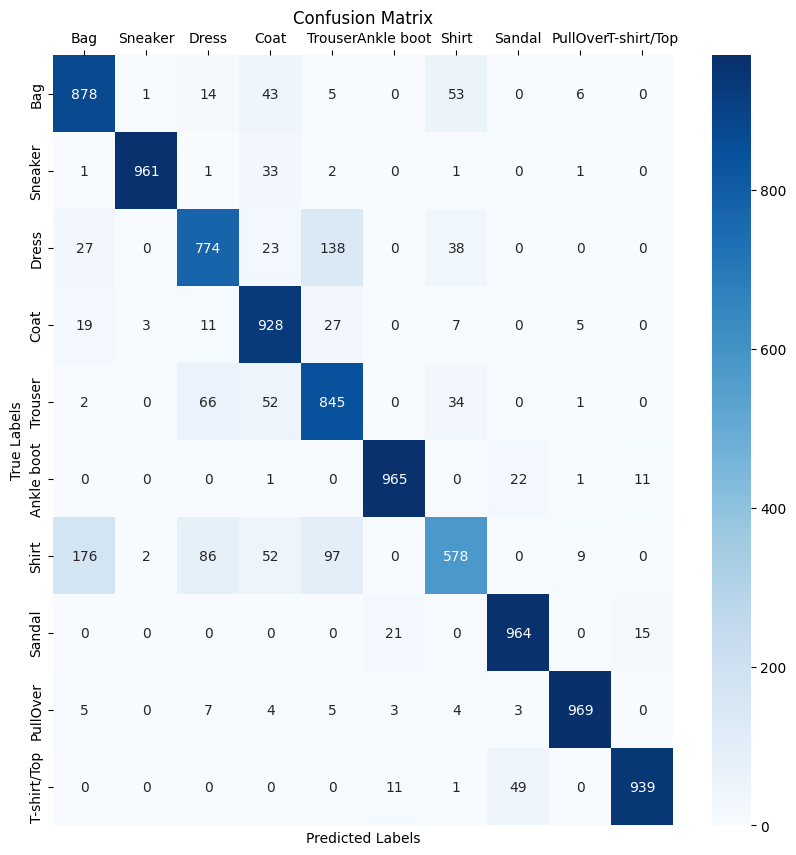

In [ ]:
conf_mat(test_labels, preds)

In [ ]:
# Create a function to plot a random image, make a prediction on the image, label the plot with truth label and predicted label
import random
def plot_random_image(model, images, true_labels, classes):
  """Picks a random image, plots it and labels it with its prediction"""
  # Sets up a random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28))
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # change the color of the titles depending on if the prediction is wrong or correct
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # add xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                 100*tf.reduce_max(pred_probs),
                                                 true_label),
           color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


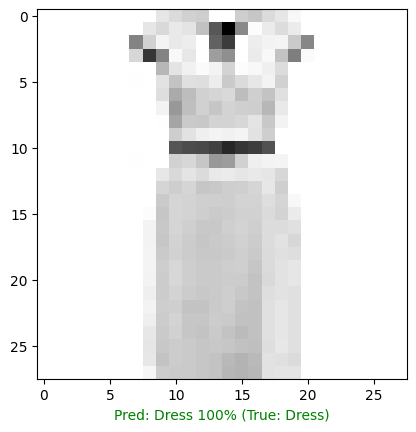

In [ ]:
# Check out a random image and prediction
plot_random_image(model=model_1,
                  images = test_data_norm,
                  true_labels = test_labels,
                  classes = label_list)

At the point of carrying out this project, i realised i had little knowledge of convolutonal neural network and so my little knowledge of neural networks was not enough to get the result i wanted